In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, logging

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

In [39]:
from pathlib import Path
DATA_DIR = Path('../data/processed/pre_processed/')
OUT_DIR  = Path('../output/')
OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. Load dữ liệu

In [40]:
df = pd.read_csv(DATA_DIR/'sales_preprocessed.csv', parse_dates=['Date'])
sales = df[['Date', 'Revenue', 'COGS']]
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


In [41]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[us]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
 3   Y        3833 non-null   int32         
 4   Q        3833 non-null   int32         
 5   M        3833 non-null   int32         
 6   DOW      3833 non-null   int32         
 7   day      3833 non-null   int32         
dtypes: datetime64[us](1), float64(2), int32(5)
memory usage: 164.8 KB


### 2. EDA
#### 2.1. Timeline Revenue & COGS

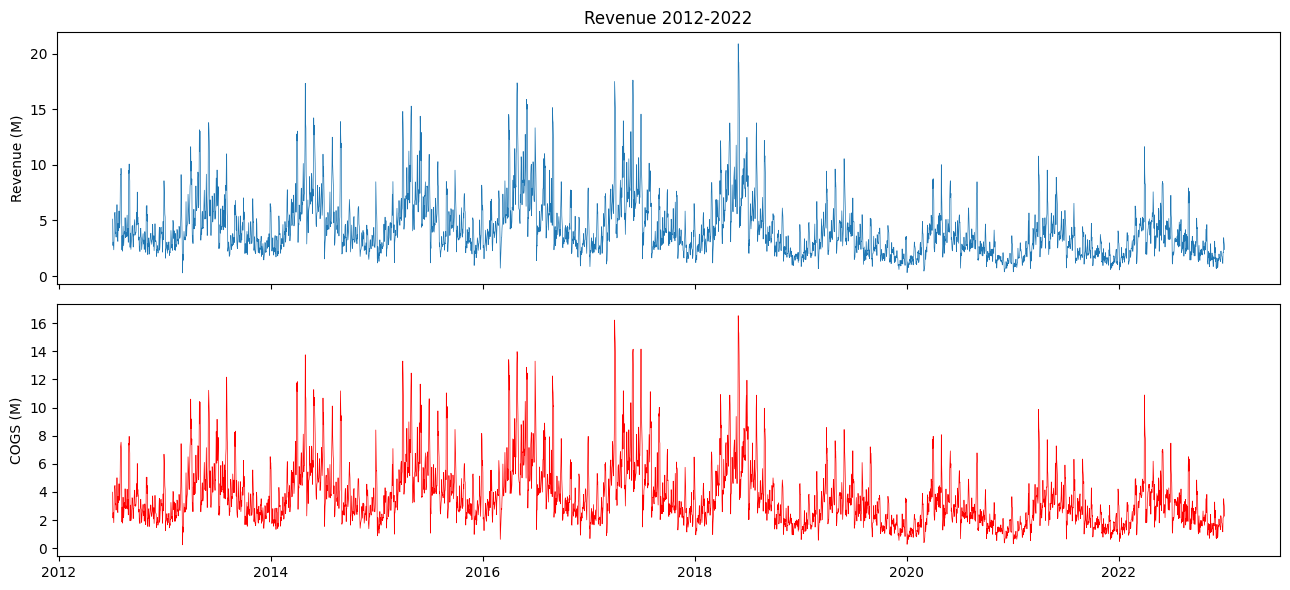

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()

- 2012 - 2013: Noise cao.
- 2014 - 2018: Biên độ doanh thu lớn nhất, seasonality rõ ràng.
- 2019: Giai đoạn chuyển tiếp -> Giảm đột ngột.
- 2020 - 2022: Regime mới, doanh thu thấp hơn 2014 - 2018, biên độ thu hẹp hơn.

#### 2.2 Monthly seasonality

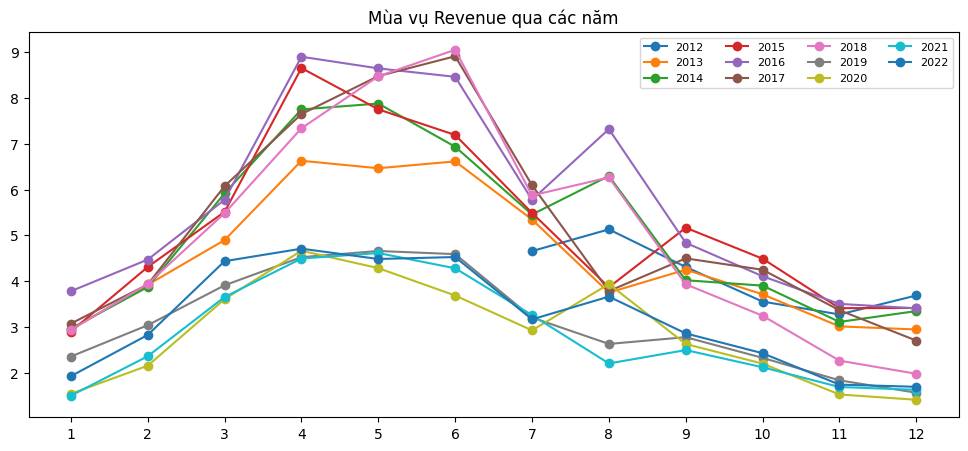

In [43]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mùa vụ Revenue qua các năm')
plt.show()

- Hình dạng mùa vụ ổn định: Tất cả các đường cong đều có cùng một dáng: đi xuống ở tháng 1–2,
bật lên ở tháng 3–4, plateau giữa năm, và bung cao ở Q4. Mùa vụ bền vững -> Level thay đổi.

-> Có thể dùng Fourier features để mô hình hoá seasonality

- Tuy nhiên có thể thấy ở tháng 8, các năm chẵn có revenue tăng, các năm lẻ giảm. Ta tiến hành kiểm tra chiến dịch khuyến mãi ở các năm chẵn/lẻ

In [44]:
df_p = pd.read_csv(DATA_DIR/'promotions_preprocessed.csv')

years = pd.to_datetime(df_p['start_date']).dt.year
even_mask = (years % 2 == 0)
odd_mask = (years % 2 != 0)

# 3. Trích xuất và làm sạch tên (Loại bỏ 4 chữ số năm ở cuối tên)
# Sử dụng regex '\s\d{4}' để tìm khoảng trắng và 4 chữ số cuối
cleaned_names = df_p['promo_name'].str.replace(r'\s\d{4}$', '', regex=True)

# 4. Tổng hợp danh sách duy nhất cho năm Chẵn và năm Lẻ
even_campaigns = cleaned_names[even_mask].unique()
odd_campaigns = cleaned_names[odd_mask].unique()

# 5. Hiển thị kết quả
print("Tổng hợp chiến dịch\n")
print(f"Năm Chẵn ({len(even_campaigns)} loại):")
print(f"   {', '.join(even_campaigns)}")

print(f"\nNăm Lẻ ({len(odd_campaigns)} loại):")
print(f"   {', '.join(odd_campaigns)}")

# 6. Tìm điểm khác biệt
differ = set(odd_campaigns) - set(even_campaigns)
if differ:
    print(f"\nChiến dịch khác biệt: {', '.join(differ)}")

Tổng hợp chiến dịch

Năm Chẵn (4 loại):
   Spring Sale, Mid-Year Sale, Fall Launch, Year-End Sale

Năm Lẻ (6 loại):
   Spring Sale, Mid-Year Sale, Fall Launch, Year-End Sale, Urban Blowout, Rural Special

Chiến dịch khác biệt: Urban Blowout, Rural Special


#### Kiểm tra xu hướng doanh thu theo năm chẵn/lẻ

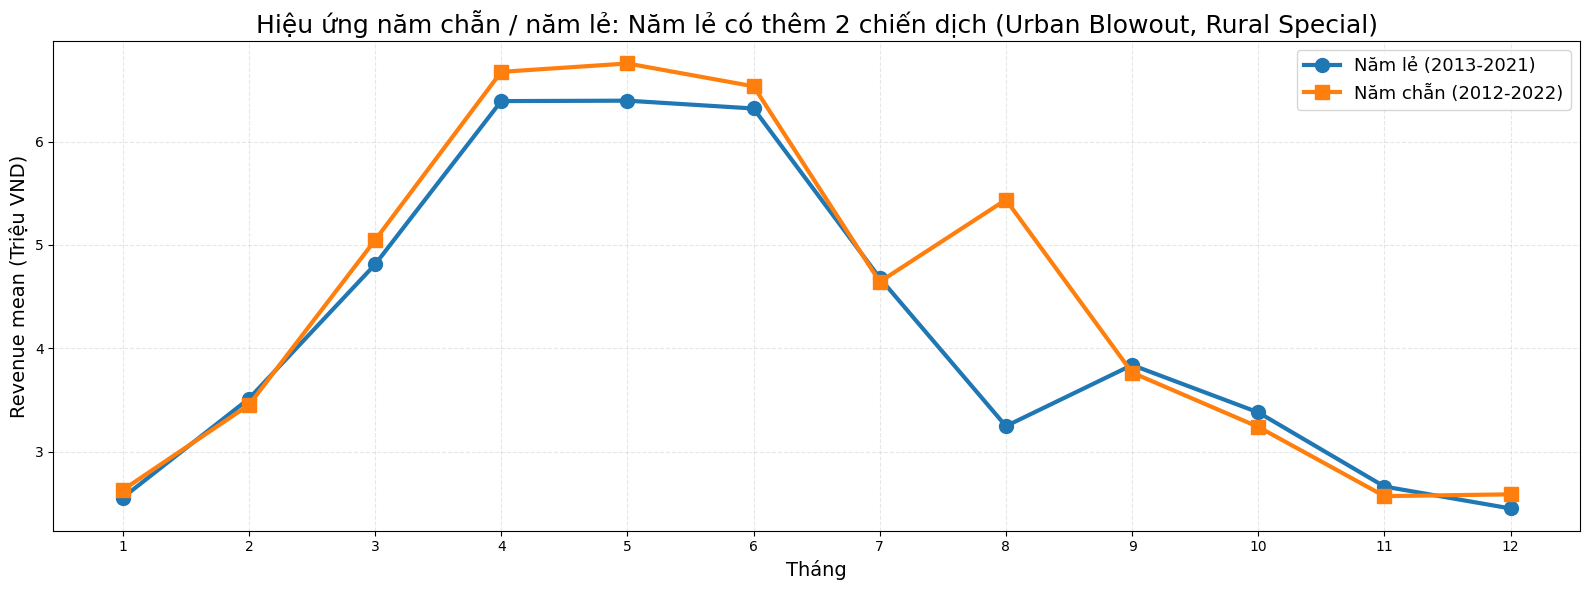

In [45]:
# Tạo bảng aggregate cho năm chẵn / năm lẻ
month_year_effect = (
    sales.assign(
        year_type=sales['Y'].apply(
            lambda y: 'Năm lẻ (2013-2021)' if y % 2 == 1
            else 'Năm chẵn (2012-2022)'
        )
    )
    .groupby(['year_type', 'M'], as_index=False)['Revenue']
    .mean()
)

# Tách ra 2 nhóm
odd_year = month_year_effect[
    month_year_effect['year_type'] == 'Năm lẻ (2013-2021)'
]

even_year = month_year_effect[
    month_year_effect['year_type'] == 'Năm chẵn (2012-2022)'
]

# ===== Plot =====
plt.figure(figsize=(16, 6))

# Năm lẻ
plt.plot(
    odd_year['M'],
    odd_year['Revenue'] / 1e6,
    marker='o',
    markersize=10,
    linewidth=3,
    label='Năm lẻ (2013-2021)'
)

# Năm chẵn
plt.plot(
    even_year['M'],
    even_year['Revenue'] / 1e6,
    marker='s',
    markersize=10,
    linewidth=3,
    label='Năm chẵn (2012-2022)'
)

plt.title(
    'Hiệu ứng năm chẵn / năm lẻ: Năm lẻ có thêm 2 chiến dịch (Urban Blowout, Rural Special)',
    fontsize=18
)

plt.xlabel('Tháng', fontsize=14)
plt.ylabel('Revenue mean (Triệu VND)', fontsize=14)

plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(
    loc='upper right',
    fontsize=13
)

plt.tight_layout()
plt.show()

- Ở tháng 8 ta thấy năm chẵn có doanh thu cao đột biến chênh gần. Các tháng còn lại gần như trùng nhau. Pattern này nhất quán qua các năm, không phải nhiễu ngẫu nhiên. Vì test gồm 2023 (năm lẻ) và 2024 (năm chẵn), tạo feature binary `is_odd_year` cho phép mô hình chuyển đổi giữa hai pattern trong từng năm của giai đoạn test.

#### 2.3 Quarterly margin

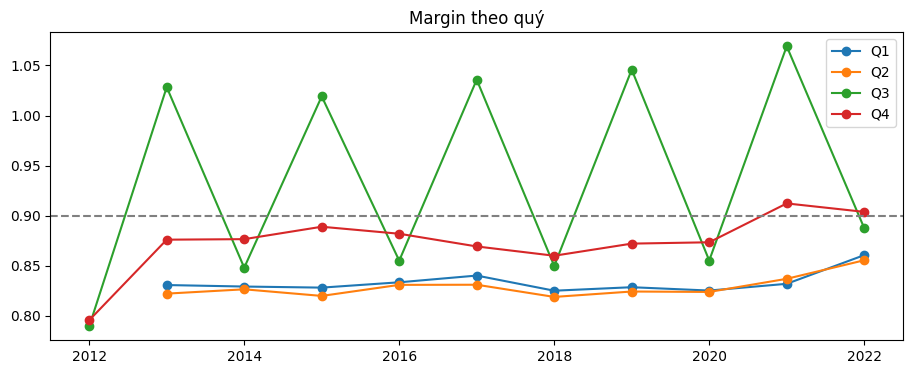

In [46]:
q_marg = sales.groupby(['Y','Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups=False).reset_index()
q_marg.columns = ['Y','Q','margin']

fig, ax = plt.subplots(figsize=(11, 4))
for q in [1,2,3,4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker='o', label=f'Q{q}')
ax.axhline(0.9, color='gray', ls='--')
ax.set_title('Margin theo quý')
ax.legend(); plt.show()

- Quan sát thấy Q3 tăng giảm theo năm chẵn/lẻ

#### Kiểm tra doanh thu theo tuần/tháng

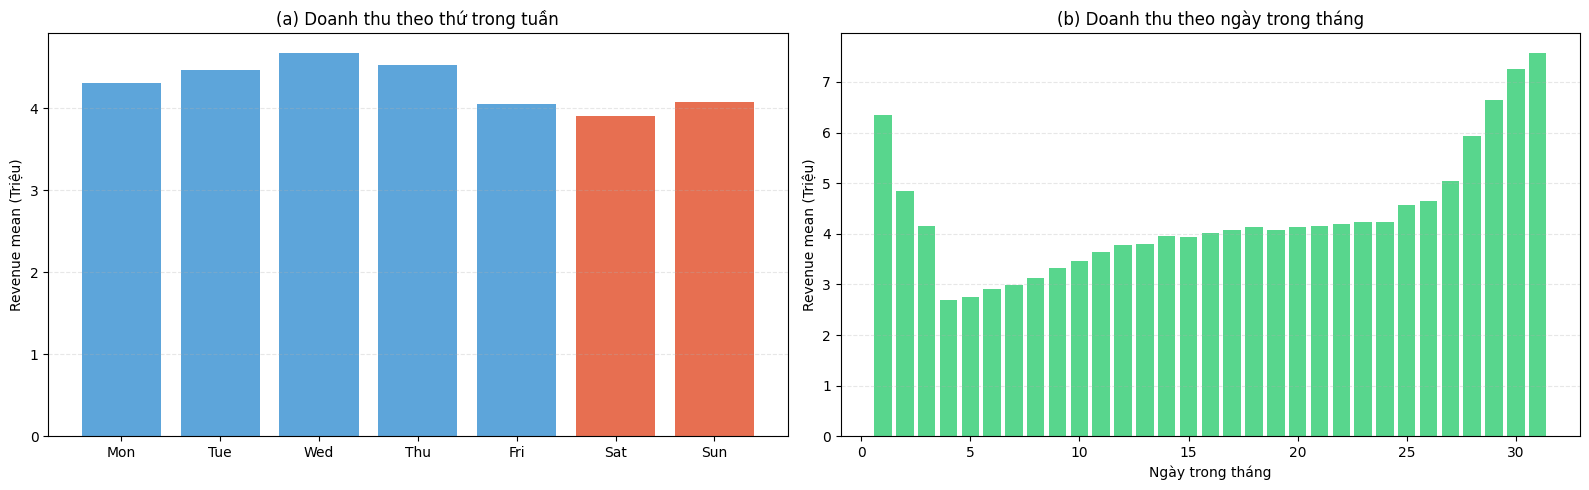

In [47]:
# Revenue theo thứ trong tuần
weekday_rev = (
    sales.groupby('DOW', as_index=False)['Revenue']
    .mean()
)

weekday_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed',
    3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

weekday_rev['weekday_name'] = weekday_rev['DOW'].map(weekday_map)

# Revenue theo ngày trong tháng 
monthday_rev = (
    sales.groupby('day', as_index=False)['Revenue']
    .mean()
    .sort_values('day')
)

# Plot 
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5)
)

# Biểu đồ (a)
week_colors = ['#5DA5DA'] * 5 + ['#E76F51'] * 2

axes[0].bar(
    weekday_rev['weekday_name'],
    weekday_rev['Revenue'] / 1e6,
    color=week_colors
)

axes[0].set_title('(a) Doanh thu theo thứ trong tuần')
axes[0].set_ylabel('Revenue mean (Triệu)')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Biểu đồ (b)
axes[1].bar(
    monthday_rev['day'],
    monthday_rev['Revenue'] / 1e6,
    color='#58D68D'
)

axes[1].set_title('(b) Doanh thu theo ngày trong tháng')
axes[1].set_xlabel('Ngày trong tháng')
axes[1].set_ylabel('Revenue mean (Triệu)')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Doanh nghiệp này có hiệu ứng weekend ngược — weekday (Mon-Fri khoảng 4.0–4.7 triệu) cao hơn weekend (Sat-Sun khoảng 3.9–4.1 triệu), khác với retail B2C thông thường. 
- Pattern day-of-month rất mạnh: doanh ngày 28–31 cuối tháng cao gấp đôi ngày giữa tháng, ngày 1–3 cũng cao (khoảng 5–6 triệu). Vùng doanh thu giữa tháng (ngày 4–20) là vùng trũng thấp. Quan sát “cuối tháng quan trọng hơn đầu tháng” dẫn đến nhóm feature `is_last1`, `is_last2`, `is_last3` và `days_to_eom`, song song với nhóm `is_first1..3` cho đầu tháng.

### 3. Feature Engineering

In [48]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15,   'odd'),
]

TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

Kiểm tra hiệu ứng tết

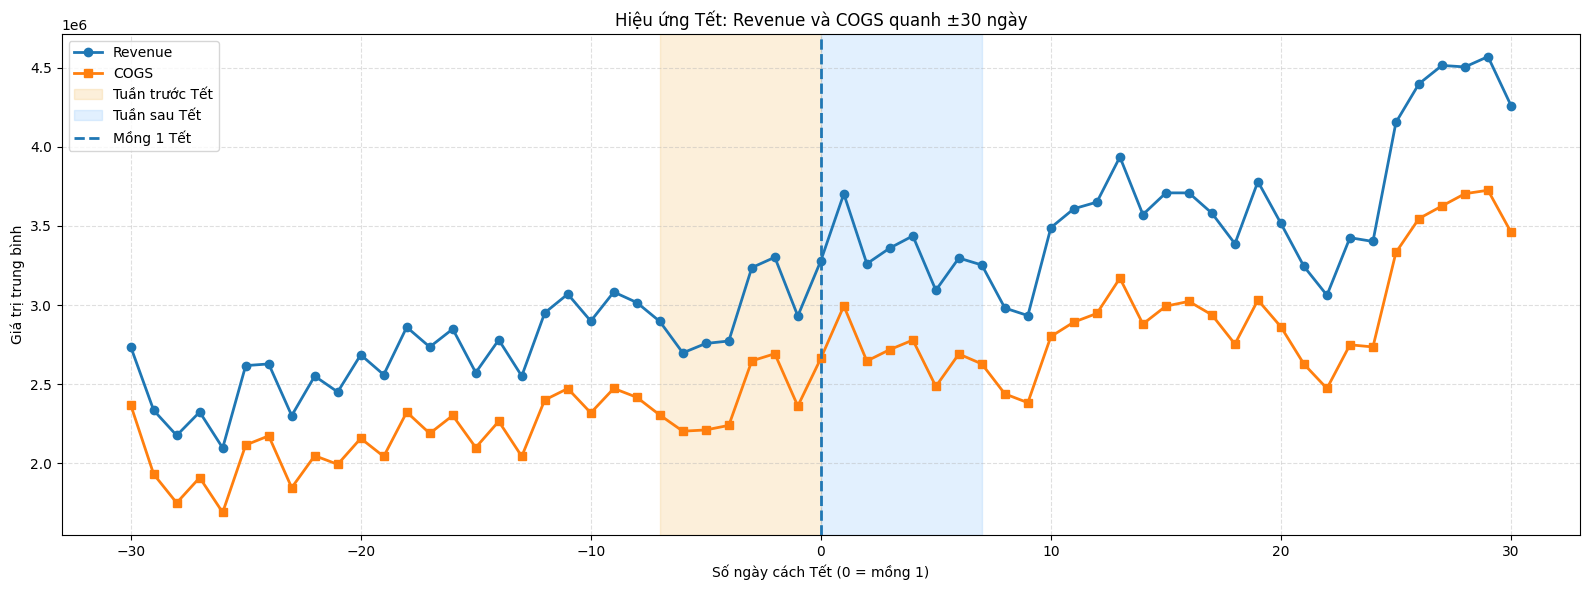

In [49]:
# map ngày Tết theo năm
tet_dates = {
    year: pd.to_datetime(date)
    for year, date in TET_DATES.items()
}

tet_effect = (
    sales.assign(
        tet_date=sales['Date'].dt.year.map(tet_dates),
        day_offset=lambda x: (x['Date'] - x['tet_date']).dt.days
    )
    .dropna(subset=['tet_date'])
    .query('day_offset >= -30 and day_offset <= 30')
    .groupby('day_offset', as_index=False)[['Revenue', 'COGS']]
    .mean()
)

# Plot 
plt.figure(figsize=(16, 6))

# Revenue
plt.plot(
    tet_effect["day_offset"],
    tet_effect["Revenue"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

# COGS
plt.plot(
    tet_effect["day_offset"],
    tet_effect["COGS"],
    marker="s",
    linewidth=2,
    label="COGS"
)

# tuần trước Tết
plt.axvspan(
    -7, 0,
    color="#F5C16C",
    alpha=0.25,
    label="Tuần trước Tết"
)

# tuần sau Tết
plt.axvspan(
    0, 7,
    color="#8EC5FC",
    alpha=0.25,
    label="Tuần sau Tết"
)

# mồng 1
plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Mồng 1 Tết"
)

plt.title("Hiệu ứng Tết: Revenue và COGS quanh ±30 ngày")
plt.xlabel("Số ngày cách Tết (0 = mồng 1)")
plt.ylabel("Giá trị trung bình")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

- Trước Tết 30 ngày, doanh thu thấp (khoảng 2.5–3.0 triệu); càng gần mồng 1, doanh thu tăng dần chứ không sụt — đỉnh nhỏ ngay quanh mồng 1 (khoảng 3.5–3.7 triệu).
- Sau Tết khoảng 20 ngày, doanh thu tăng lên (khoảng 4–4.5 triệu). Revenue và COGS đi song song.  Tết rơi vào các ngày dương lịch khác nhau mỗi năm (từ 21/01 đến 19/02) -> feature cố định theo tháng không bắt được -> Dùng feature khoảng cách tới Tết gần nhất — biến `tet_days_diff` mã hoá chính xác đặc điểm này và áp dụng được cho cả 2023 (Tết 22/01) lẫn 2024 (Tết 10/02).

In [50]:
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # Calendar
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow']>=5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge of month
    for k in [1,2,3]:
        df[f'is_last{k}']  = (df['days_to_eom']  <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # Trend + regime
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # Fourier
    TAU = 2*np.pi
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(TAU*k*df['doy']/365.25)
        df[f'cos_y{k}'] = np.cos(TAU*k*df['doy']/365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU*k*df['dow']/7.0)
        df[f'cos_w{k}'] = np.cos(TAU*k*df['dow']/7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU*k*(df['day']-1)/df['dim'])

    # Holidays
    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month']==m) & (df['day']==dd_)).astype(int)

    # Tet distance
    tet_lut = {y: pd.Timestamp(v) for y,v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        cands = [tet_lut.get(dd.year), tet_lut.get(dd.year-1), tet_lut.get(dd.year+1)]
        cands = [c for c in cands if c is not None]
        valid = [(dd-c).days for c in cands if abs((dd-c).days)<=45]
        return min(valid) if valid else 999
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7']      = (np.abs(diffs)<=7).astype(int)
    df['tet_in_14']     = (np.abs(diffs)<=14).astype(int)
    df['tet_before_7']  = ((diffs>=-7) & (diffs<0)).astype(int)
    df['tet_after_7']   = ((diffs>0) & (diffs<=7)).astype(int)
    df['tet_on']        = (diffs==0).astype(int)

    # Black Friday
    def is_bf(dd):
        if dd.month != 11: return 0
        last = pd.Timestamp(year=dd.year, month=11, day=30)
        last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
        return int(dd == last_fri)
    df['hol_black_friday'] = [is_bf(dd) for dd in d]

    # Promo windows
    yrs = sorted(set(df['year'].tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount= np.zeros(len(df))
        for y in range(min(yrs)-1, max(yrs)+2):
            if recur=='odd' and y%2==0: continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d>=start) & (d<=end)
            in_prom[mask] = 1
            since[mask]   = (d[mask]-start).dt.days
            until[mask]   = (end-d[mask]).dt.days
            discount[mask]= disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01','2023-01-05')).shape)

Test: (5, 82)


### 4. Chuẩn bị data train + test

In [51]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')

Training: (3833, 81), Test: (548, 81), Features: 81


### 5. Lưu file Features

In [52]:
# Tạo thư mục chứa feature đã xử lý nếu chưa có
os.makedirs('../data/features/', exist_ok=True)

# 1. Lưu DataFrame bằng định dạng Parquet
feat.to_parquet('../data/features/train_feat.parquet', index=False)
test_df.to_parquet('../data/features/test_feat.parquet', index=False)

# 2. Lưu mảng Numpy (y_rev, y_cog dạng log)
np.save('../data/features/y_rev.npy', y_rev)
np.save('../data/features/y_cog.npy', y_cog)

print("Đã lưu toàn bộ Features và Target")

Đã lưu toàn bộ Features và Target
